<a href="https://colab.research.google.com/github/SaadullahIsmail9/mitr-take-home-eval/blob/main/saad_part_d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PART D: Inter-layer CKA Similarity Probe
# Measures redundancy between adjacent layers in BERT vs RoBERTa
# before any fine-tuning — tests whether pretraining explains
# MITR's opposite effects on the two backbones

!pip install -q transformers datasets matplotlib seaborn
print("Done.")

Done.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertModel, RobertaModel, BertTokenizerFast, RobertaTokenizerFast
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
# Load a small sample of BoolQ to run through the models
dataset = load_dataset("boolq", split="validation[:200]")

def get_texts(dataset):
    return [f"{ex['passage'][:256]} {ex['question']}" for ex in dataset]

texts = get_texts(dataset)
print(f"Loaded {len(texts)} examples")

Loaded 200 examples


In [ ]:
def compute_cka(X, Y):
    """Linear CKA between two layer output matrices."""
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    dot_xx = (X @ X.T).norm() ** 2
    dot_yy = (Y @ Y.T).norm() ** 2
    dot_xy = (X @ Y.T).norm() ** 2
    return (dot_xy / (dot_xx.sqrt() * dot_yy.sqrt())).item()

def get_layer_representations(model, tokenizer, texts, device, batch_size=16):
    """Extract CLS token from every layer for all texts."""
    model.eval()
    model.to(device)
    all_hidden_states = None

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True,
                           max_length=256, return_tensors="pt").to(device)
            out = model(**enc, output_hidden_states=True)
            # hidden_states: tuple of (num_layers+1, batch, seq, hidden)
            # take CLS token from each layer
            hs = torch.stack([h[:, 0, :].cpu() for h in out.hidden_states[1:]], dim=0)
            if all_hidden_states is None:
                all_hidden_states = hs
            else:
                all_hidden_states = torch.cat([all_hidden_states, hs], dim=1)

    return all_hidden_states  # (num_layers, num_texts, hidden_size)

print("CKA functions defined.")

CKA functions defined.


In [ ]:
# Load BERT and RoBERTa (no fine-tuning — pretrained weights only)
print("Loading BERT...")
bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

print("Loading RoBERTa...")
roberta_tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
roberta_model = RobertaModel.from_pretrained("roberta-base")

print("Both models loaded!")

Loading BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading RoBERTa...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Both models loaded!


In [ ]:
# Extract layer representations for both models
print("Extracting BERT layer representations...")
bert_hidden = get_layer_representations(bert_model, bert_tokenizer, texts, device)
print(f"BERT hidden states shape: {bert_hidden.shape}")  # (12, 200, 768)

print("Extracting RoBERTa layer representations...")
roberta_hidden = get_layer_representations(roberta_model, roberta_tokenizer, texts, device)
print(f"RoBERTa hidden states shape: {roberta_hidden.shape}")  # (12, 200, 768)

print("Done!")

Extracting BERT layer representations...
BERT hidden states shape: torch.Size([12, 200, 768])
Extracting RoBERTa layer representations...
RoBERTa hidden states shape: torch.Size([12, 200, 768])
Done!


In [ ]:
# Compute pairwise CKA similarity matrix for each model
def compute_cka_matrix(hidden_states):
    num_layers = hidden_states.shape[0]
    cka_matrix = np.zeros((num_layers, num_layers))
    for i in range(num_layers):
        for j in range(num_layers):
            cka_matrix[i, j] = compute_cka(hidden_states[i], hidden_states[j])
    return cka_matrix

print("Computing BERT CKA matrix...")
bert_cka = compute_cka_matrix(bert_hidden)

print("Computing RoBERTa CKA matrix...")
roberta_cka = compute_cka_matrix(roberta_hidden)

print("Done!")
print(f"BERT mean adjacent-layer CKA: {np.mean([bert_cka[i,i+1] for i in range(11)]):.4f}")
print(f"RoBERTa mean adjacent-layer CKA: {np.mean([roberta_cka[i,i+1] for i in range(11)]):.4f}")

Computing BERT CKA matrix...
Computing RoBERTa CKA matrix...
Done!
BERT mean adjacent-layer CKA: 0.5182
RoBERTa mean adjacent-layer CKA: 0.3513


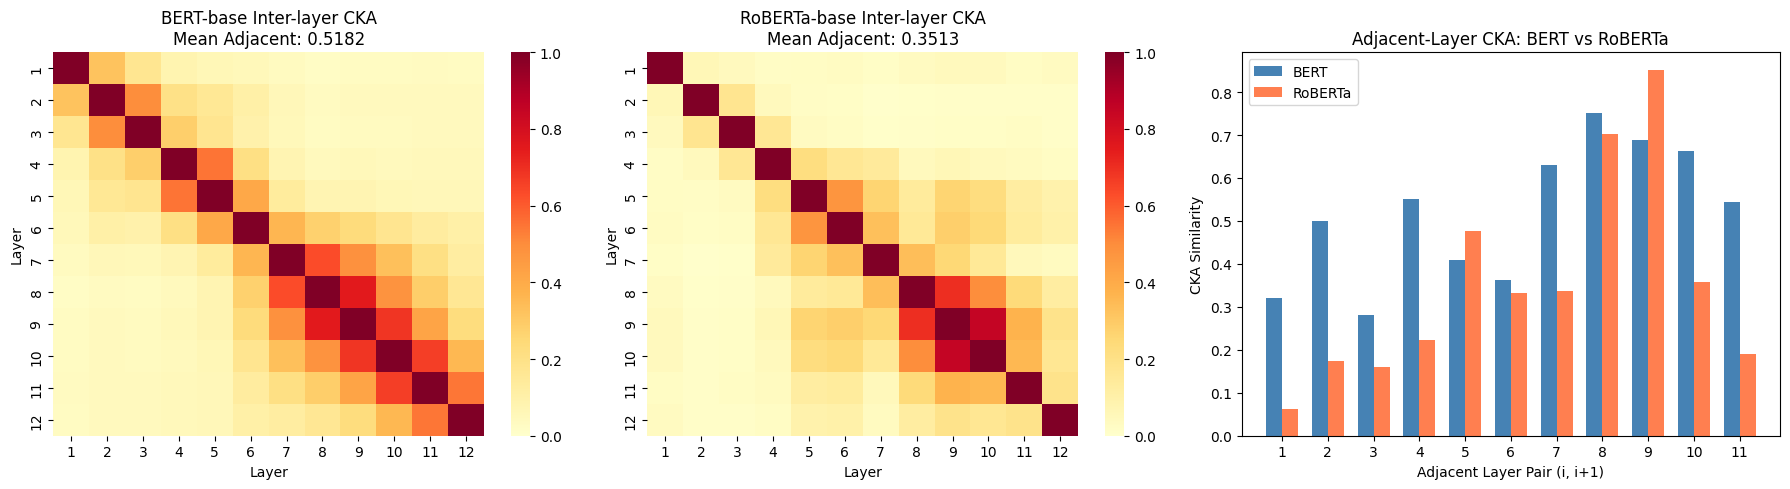

Chart saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BERT heatmap
sns.heatmap(bert_cka, ax=axes[0], cmap="YlOrRd", vmin=0, vmax=1,
            xticklabels=range(1,13), yticklabels=range(1,13))
axes[0].set_title(f"BERT-base Inter-layer CKA\nMean Adjacent: {np.mean([bert_cka[i,i+1] for i in range(11)]):.4f}", fontsize=12)
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Layer")

# RoBERTa heatmap
sns.heatmap(roberta_cka, ax=axes[1], cmap="YlOrRd", vmin=0, vmax=1,
            xticklabels=range(1,13), yticklabels=range(1,13))
axes[1].set_title(f"RoBERTa-base Inter-layer CKA\nMean Adjacent: {np.mean([roberta_cka[i,i+1] for i in range(11)]):.4f}", fontsize=12)
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Layer")

# Bar chart of adjacent-layer CKA scores
bert_adj = [bert_cka[i,i+1] for i in range(11)]
roberta_adj = [roberta_cka[i,i+1] for i in range(11)]
x = np.arange(1, 12)
width = 0.35
axes[2].bar(x - width/2, bert_adj, width, label="BERT", color="steelblue")
axes[2].bar(x + width/2, roberta_adj, width, label="RoBERTa", color="coral")
axes[2].set_xlabel("Adjacent Layer Pair (i, i+1)")
axes[2].set_ylabel("CKA Similarity")
axes[2].set_title("Adjacent-Layer CKA: BERT vs RoBERTa", fontsize=12)
axes[2].legend()
axes[2].set_xticks(x)

plt.tight_layout()
plt.savefig("part_d_cka_probe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved!")